# Low-latency fan-out transport — measurements

A shared-memory-to-shared-memory relay, measured **over a real network** between two
hosts on the same L2 subnet:

```
host A                                    host B
producer -> shm ring -> sender  ==NIC==>  receiver -> shm ring -> consumer
 (given)                (ours)             (ours)                 (given)
```

Design reasoning is in [SOLUTION.md](SOLUTION.md); this notebook is the evidence.

**Everything here crosses a real NIC.** An earlier revision reported loopback
figures as headline results, which understated latency by roughly 15x: loopback has
no driver, no NIC and no wire, so it measures the software path only. Loopback now
appears nowhere in this notebook.

**Headline, 200k msg/s, 20M samples per repetition:**

| | |
|---|---|
| p50 | **35.0 µs** |
| p99 | **39.3 µs** |
| p99.9 | **49.8 µs** |
| p99.99 | **68.1 µs** |
| p99.999 | 1.06 ms |
| drop rate | **0.0000%** |
| our code's share of the 35 µs | **~620 ns (1.8%)** |

Three findings worth the read:

1. **The transport is not the bottleneck; the network path is.** Per-stage timing
   shows our sender costs 305 ns, publishing into the receiver's ring costs 50 ns,
   and the consumer picks it up 264 ns later. The remaining 34.3 µs is kernel TX,
   NIC, wire and kernel RX. See figure 2.
2. **Loss tracks packet rate, not message rate.** The only loss anywhere in the
   sweep (0.0088%) is at the *highest packet rate*, which is 1M msg/s -- not at 2M,
   where batching pushes packets per second back down. See figure 7.
3. **Latency spikes are not uniformly distributed — they arrive in bursts**, and the
   larger the spike the more strictly that holds. Every excursion above 500 µs, in
   every repetition, belongs to a burst of consecutive messages; not one occurs in
   isolation. A whole 20M-message run's far tail comes down to one to three discrete
   events. See figure 3.
4. **Those bursts are a queue draining.** All 213 messages over 1 ms are
   wire-dominated, and they arrive as consecutive sequence ids whose latency falls by
   the inter-message interval. See figures 4-5.
5. **Loss is bursty too, which means duplication buys almost nothing here.** This path
   loses 2 × 10⁻⁵ of messages, and those losses arrive in a handful of events of ~70
   consecutive datagrams. A copy sent microseconds after its original dies inside the
   same burst: 2 rescues out of 485 lost datagrams. See figure 7b.
6. **Fan-out is limited by packets, not by our code.** Each receiver costs one more
   packet per datagram, so the NIC's packet-rate ceiling divides the achievable message
   rate by receiver count. At ten receivers we are already at 97% of it. See figure 8.

## Methodology

**Metric collection cannot be allowed to perturb the metric.** Samples go into
memory reserved *and page-touched* before the first sample, `record()` is a couple
of stores, and nothing reaches the filesystem until the run is over. An earlier
version wrote one CSV line per message from inside the measurement loop; on a
disk-backed filesystem that alone cost ~1 ms at p99.99, and even on tmpfs a `write`
can stall unpredictably. Every number below was collected with the allocation-free
path.

**Sample counts are sized to the percentile being claimed.** A percentile needs
roughly a hundred observations beyond it to mean anything, so p99.999 needs ~10M
samples. The rate sweep uses 20M samples per repetition wherever the rate allows it
in a sane run length. At 100 and 10k events/second it cannot -- 20M samples at 100/s
is two days -- so those rows are marked and their far tail is *not* reported.

**Other rules applied throughout:**

- Steady state only: the stream runs continuously, consumers attach at the live edge
  after an 8 s warm-up, and the first samples of each run are discarded.
- Percentiles are medians across repetitions with the lo..hi spread shown, so a
  figure whose repetitions disagree looks uncertain rather than authoritative.
- Cores are verified idle, isolated and free of SMT siblings before every run
  (`scripts/check_cores.sh`), which refuses to measure otherwise. It caught a
  leftover producer pinned to a measurement core twice during this work.
- Figures are static images so they render in any repository viewer without
  JavaScript, and every figure is followed by its table view.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS = Path("data/plots")

# ---- palette -----------------------------------------------------------------
# Checked with a palette validator. Percentiles are an *ordered* progression, so
# they use an ordinal single-hue ramp; things that are merely different (pipeline
# stages, send methods, receive modes) use categorical slots. Slots 3 and 4 fall
# below 3:1 against this surface, so those figures carry direct labels and a table
# view rather than relying on fill alone.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
ORD4 = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]
ORD6 = ["#b7d3f6", "#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
CAT  = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 120,
    "font.family": "sans-serif", "font.size": 9,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2, "lines.markersize": 5.5,
})


def style(ax, ylabel=None, xlabel=None, grid_axis="y"):
    'Recessive chrome: hairline grid, only the spines that carry meaning.'
    ax.grid(True, axis=grid_axis, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax


def ns(x, _=None):
    return f"{x:,.0f}"


def rate_fmt(v, _=None):
    return f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")


def table(df, caption=None):
    'The table view that accompanies every figure.'
    if caption:
        print(caption)
    return df

## 1. Delivery latency against offered rate

The task's stated range is 100 events/second to 2M. Log axes on both, because rates
span four orders of magnitude and latencies three.

**What to look for:** p50 through p99.99 are remarkably flat across the whole range
-- 35 to 47 µs at the median over a 20,000x change in rate. The *lowest* rate has the
*highest* median, which is the opposite of a congestion effect: at 100 events/second
messages arrive 10 ms apart and every one of them hits cold caches and a cold TLB.
Throughput is not the constraint anywhere in this range.

p99.999 is plotted with hollow markers where the sample count cannot support it.

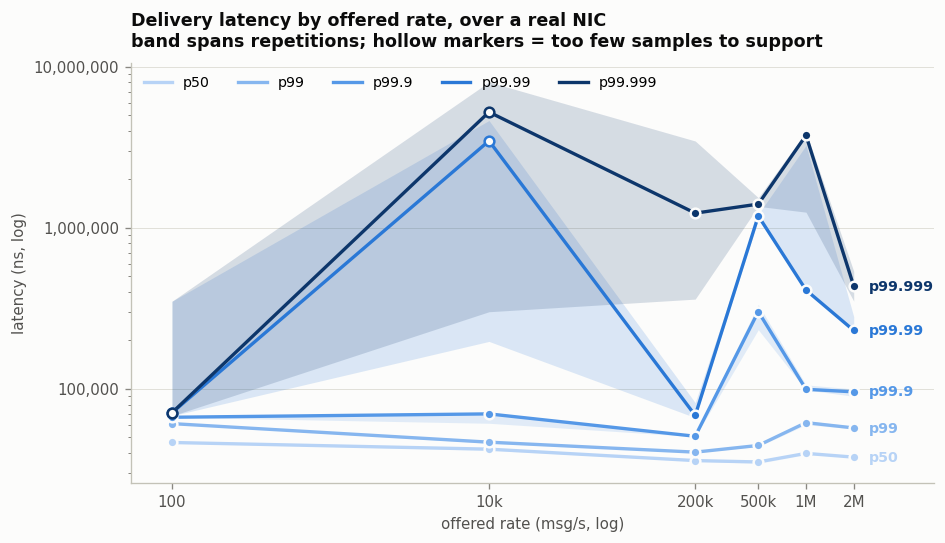

In [2]:
lvr = pd.read_csv(PLOTS / "latency_vs_rate.csv")
pcts = [("p50", "p50"), ("p99", "p99"), ("p99.9", "p99.9"),
        ("p99.99", "p99.99"), ("p99.999", "p99.999")]

fig, ax = plt.subplots(figsize=(8.0, 4.6))
for (col, label), colour in zip(pcts, [ORD6[0], ORD6[1], ORD6[2], ORD6[3], ORD6[5]]):
    ax.fill_between(lvr["rate"], lvr[f"{col}_lo"], lvr[f"{col}_hi"],
                    color=colour, alpha=0.16, linewidth=0, zorder=2)
    ax.plot(lvr["rate"], lvr[col], color=colour, label=label, zorder=3)
    # Solid where the sample count supports the percentile, hollow where it does not.
    if col in ("p99.99", "p99.999"):
        key = "p99.99_supported" if col == "p99.99" else "p99.999_supported"
        ok = lvr[key].fillna(0).astype(int) == 1
        ax.scatter(lvr["rate"][ok], lvr[col][ok], color=colour, s=34,
                   edgecolor=SURFACE, linewidth=1.5, zorder=4)
        ax.scatter(lvr["rate"][~ok], lvr[col][~ok], facecolor=SURFACE, s=34,
                   edgecolor=colour, linewidth=1.5, zorder=4)
    else:
        ax.scatter(lvr["rate"], lvr[col], color=colour, s=34,
                   edgecolor=SURFACE, linewidth=1.5, zorder=4)
    ax.annotate(label, (lvr["rate"].iloc[-1], lvr[col].iloc[-1]),
                textcoords="offset points", xytext=(9, 0), va="center",
                color=colour, fontsize=8.5, fontweight="600")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Delivery latency by offered rate, over a real NIC\n"
             "band spans repetitions; hollow markers = too few samples to support")
style(ax, ylabel="latency (ns, log)", xlabel="offered rate (msg/s, log)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.set_xticks(lvr["rate"].tolist())
ax.set_xticklabels([rate_fmt(r) for r in lvr["rate"]])
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlim(lvr["rate"].min() * 0.55, lvr["rate"].max() * 3.2)
ax.legend(loc="upper left", ncols=5)
plt.tight_layout(); plt.show()

In [3]:
t = lvr[["rate", "samples", "min", "p50", "p99", "p99.9", "p99.99", "p99.999",
         "max", "drop_pct"]].copy()
t.columns = ["rate", "samples/run", "min", "p50", "p99", "p99.9", "p99.99",
             "p99.999", "max", "drop %"]
table(t.style.format({c: "{:,.0f}" for c in t.columns if c != "drop %"} |
                     {"drop %": "{:.4f}"}).hide(axis="index"),
      "Table 1 - latency in ns. p99.99 needs ~1M samples and p99.999 ~10M; "
      "the 100 and 10k rows do not have them and their far tail is not reported.")

Table 1 - latency in ns. p99.99 needs ~1M samples and p99.999 ~10M; the 100 and 10k rows do not have them and their far tail is not reported.


rate,samples/run,min,p50,p99,p99.9,p99.99,p99.999,max,drop %
100,"5,400","42,289","46,470","60,880","66,660","71,097","71,097","71,097",0.0000
"10,000","383,616","35,031","42,249","46,685","69,952","3,469,682","5,238,034","5,450,816",0.0000
"200,000","19,983,616","33,076","35,876","40,479","50,804","68,409","1,234,270","1,895,327",0.0000
"500,000","19,983,616","31,795","35,180","44,549","301,926","1,186,432","1,404,812","1,512,293",0.0000
"1,000,000","19,983,616","32,815","39,768","61,730","99,418","410,964","3,750,633","3,839,420",0.0088
"2,000,000","19,983,616","31,566","37,696","57,227","95,886","230,643","435,313","488,242",0.0000


## 2. Where the time actually goes

The sender stamps departure into the datagram header, the receiver stamps arrival and
publication, and joining on `seq_id` against the consumer's own timestamp gives the
fourth leg. Four legs, 20M messages, at 200k msg/s:

- **source ring + sender** — producer's stamp to the sender handing it to the kernel
- **wire** — kernel TX, NIC, cable, NIC RX, kernel RX
- **arrival → published** — receiver parsing and publishing into its ring
- **published → consumer** — the consumer's ring read

**What to look for:** the wire is everything. Our three legs together cost about
620 ns at the median out of 35 µs, and stay under 1 µs even at p99.999. There is no
optimisation left in our code that could matter at this scale -- the remaining lever
is the kernel network stack itself, which means kernel bypass.

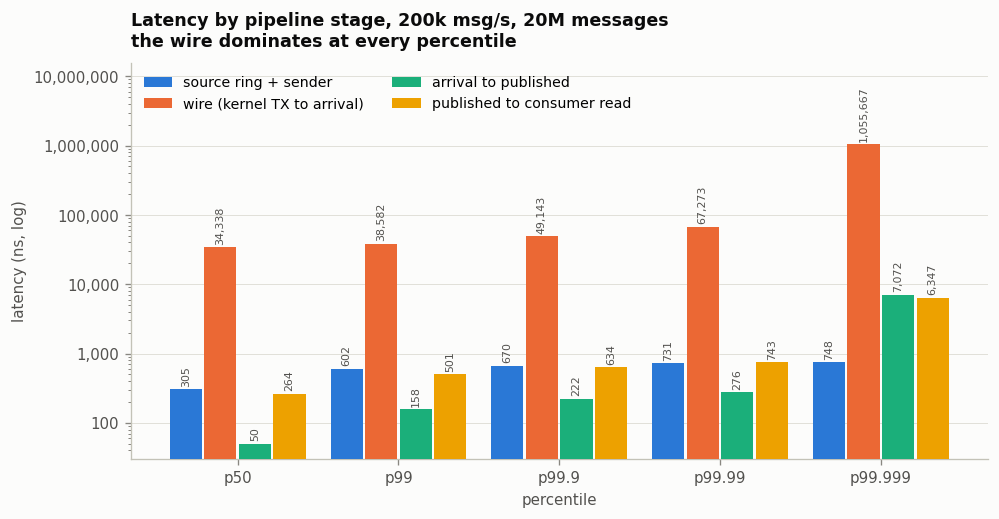

In [4]:
st = pd.read_csv(PLOTS / "stage_breakdown.csv")
legs = st[st["stage"] != "end to end"].reset_index(drop=True)
cols = ["p50", "p99", "p99.9", "p99.99", "p99.999"]
x = np.arange(len(cols))
w = 0.2

fig, ax = plt.subplots(figsize=(8.4, 4.4))
for i, row in legs.iterrows():
    vals = [row[c] for c in cols]
    off = (i - 1.5) * (w + 0.015)
    ax.bar(x + off, vals, width=w, color=CAT[i], label=row["stage"], zorder=3)
    # Direct labels: two of these fills are below 3:1 on this surface, so the
    # values must be readable without relying on colour.
    for xi, v in zip(x + off, vals):
        ax.annotate(f"{v:,.0f}", (xi, v), textcoords="offset points",
                    xytext=(0, 3), ha="center", color=INK2, fontsize=6.6,
                    rotation=90)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(cols)
ax.set_ylim(top=ax.get_ylim()[1] * 9)
ax.set_title("Latency by pipeline stage, 200k msg/s, 20M messages\n"
             "the wire dominates at every percentile")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

In [5]:
t2 = st[["stage", "samples", "p50", "p99", "p99.9", "p99.99", "p99.999",
         "p99.9999", "max"]].copy()
table(t2.style.format({c: "{:,.0f}" for c in t2.columns if c != "stage"})
      .hide(axis="index"),
      "Table 2 - the three legs we control sum to ~620 ns at the median")

Table 2 - the three legs we control sum to ~620 ns at the median


stage,samples,p50,p99,p99.9,p99.99,p99.999,p99.9999,max
source ring + sender,"20,000,000",305,602,670,731,748,761,"4,777"
wire (kernel TX to arrival),"20,000,000","34,338","38,582","49,143","67,273","1,055,667","1,870,154","1,960,424"
arrival to published,"20,000,000",50,158,222,276,"7,072","9,984","12,984"
published to consumer read,"20,000,000",264,501,634,743,"6,347","25,090","108,465"
end to end,"20,000,000","34,996","39,268","49,818","68,089","1,056,468","1,870,948","1,961,160"


## 3. What a run actually looks like, and how outliers arrive

Percentiles hide time structure completely. This is latency against position in the
run, for three separate repetitions of the *same* configuration — the baseline
decimated to an even sample, plus every point above that repetition's p99.9 so no
outlier is lost to decimation.

**What to look for — this is a headline result, not a detail:** the baseline is a
tight band that barely moves, and **the spikes are not uniformly distributed. They
arrive in bursts.** Each tall vertical stripe is many consecutive messages late
together, which is what a queue draining looks like and not what independent random
stalls look like.

Grouping the messages above a threshold into runs of consecutive arrivals quantifies
it. Independent spikes would be almost entirely runs of length one. Instead:

| spike size | isolated occurrences | inside bursts of ≥10 messages |
|---|---|---|
| above 50 µs | ~23% | ~12% |
| above 100 µs | ~0.8% | ~92% |
| above 200 µs | ~0.1% | ~98% |
| **above 500 µs** | **0%** | **100%** |

The small excursions just past p99.9 are a mix, but **every large spike belongs to a
burst — not one isolated occurrence above 500 µs in any repetition.** A 20M-message
run contains only one to three such bursts, and they are what set p99.99 and beyond.

The bursts also differ completely between repetitions of an identical configuration —
2 ms in one run, 4.5 ms in another, only 700 µs in a third — which is why a single run
cannot establish a far-tail percentile, and why averaging them would describe
something that never happened.

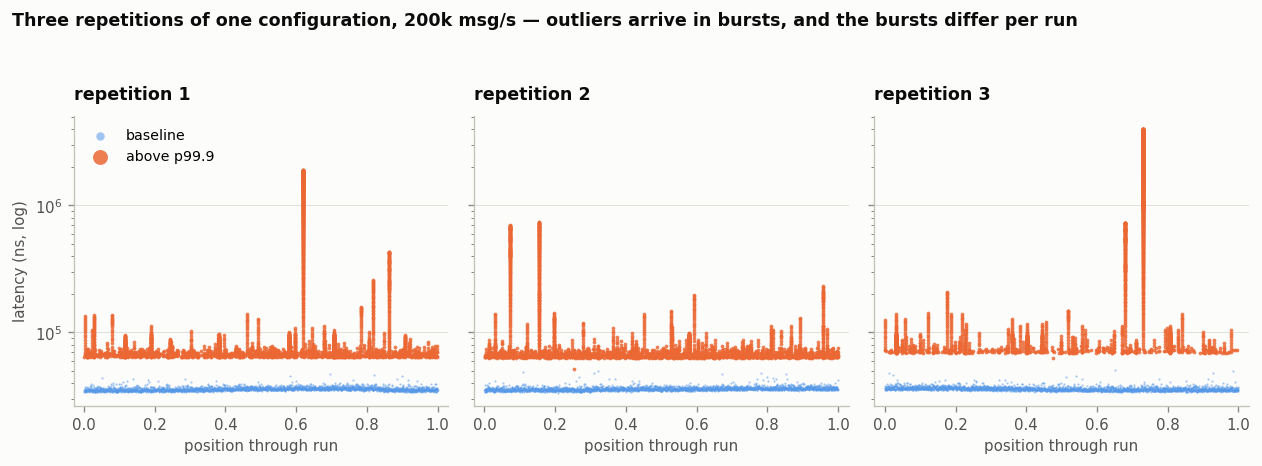

In [6]:
sc = pd.read_csv(PLOTS / "scatter_200k.csv")
reps = sorted(sc["rep"].unique())

fig, axes = plt.subplots(1, len(reps), figsize=(10.6, 3.9), sharey=True)
if len(reps) == 1:
    axes = [axes]
for ax, rep in zip(axes, reps):
    d = sc[sc["rep"] == rep]
    base, out = d[d["outlier"] == 0], d[d["outlier"] == 1]
    ax.scatter(base["fraction"], base["latency_ns"], s=1.6, color=ORD4[1],
               alpha=0.55, linewidth=0, zorder=3, label="baseline")
    ax.scatter(out["fraction"], out["latency_ns"], s=5.0, color=CAT[1],
               alpha=0.85, linewidth=0, zorder=4, label="above p99.9")
    ax.set_yscale("log")
    ax.set_title(f"repetition {rep}")
    style(ax, xlabel="position through run")
    ax.set_xlim(-0.03, 1.03)
    if ax is axes[0]:
        ax.set_ylabel("latency (ns, log)")
        ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
        ax.legend(loc="upper left", markerscale=4)
fig.suptitle("Three repetitions of one configuration, 200k msg/s — outliers arrive "
             "in bursts, and the bursts differ per run",
             x=0.012, ha="left", fontsize=10.5, fontweight="600", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

In [7]:
bs = pd.read_csv(PLOTS / "burst_stats.csv")
show = bs[["threshold_ns", "rep", "messages", "bursts", "largest_burst",
           "singleton_pct", "in_bursts_ge10_pct"]].copy()
show.columns = ["spike >", "rep", "messages", "bursts", "largest burst",
                "isolated %", "in bursts >=10 %"]
table(show.style.format({"spike >": "{:,.0f}", "messages": "{:,.0f}",
                         "bursts": "{:,.0f}", "largest burst": "{:,.0f}",
                         "isolated %": "{:.2f}", "in bursts >=10 %": "{:.2f}"})
      .hide(axis="index"),
      "Table 3 - spikes grouped into runs of consecutive messages. Independent "
      "spikes would be almost all singletons; above 500 us there are none.")

Table 3 - spikes grouped into runs of consecutive messages. Independent spikes would be almost all singletons; above 500 us there are none.


spike >,rep,messages,bursts,largest burst,isolated %,in bursts >=10 %
"50,000",1,"22,483","10,456",471,23.09,11.77
"50,000",2,"21,643","10,263",177,23.37,8.44
"50,000",3,"23,569","10,615","1,147",23.02,15.67
"100,000",1,689,23,459,1.16,92.31
"100,000",2,514,26,165,0.58,89.11
"100,000",3,"1,488",37,"1,135",0.54,94.56
"200,000",1,523,3,436,0.00,100.00
"200,000",2,289,5,139,0.35,95.85
"200,000",3,"1,271",3,"1,113",0.00,99.76
"500,000",1,366,1,366,0.00,100.00


## 4. One outlier event, message by message

Taking the single worst message in the run and plotting its neighbours by sequence
id makes the mechanism unambiguous.

**What to look for:** a near-perfect straight line descending from ~2 ms, with each
consecutive message about 4.5 µs faster than the one before — and 4.5 µs is the
inter-message interval at this rate. That is a queue that stopped being served for
about 2 ms, accumulated several hundred messages, and then drained back-to-back. It
is one stall affecting many messages, not many independent stalls.

This is also why the far tail is so sensitive to run length: a single 2 ms event
contributes hundreds of samples to p99.99 and above.

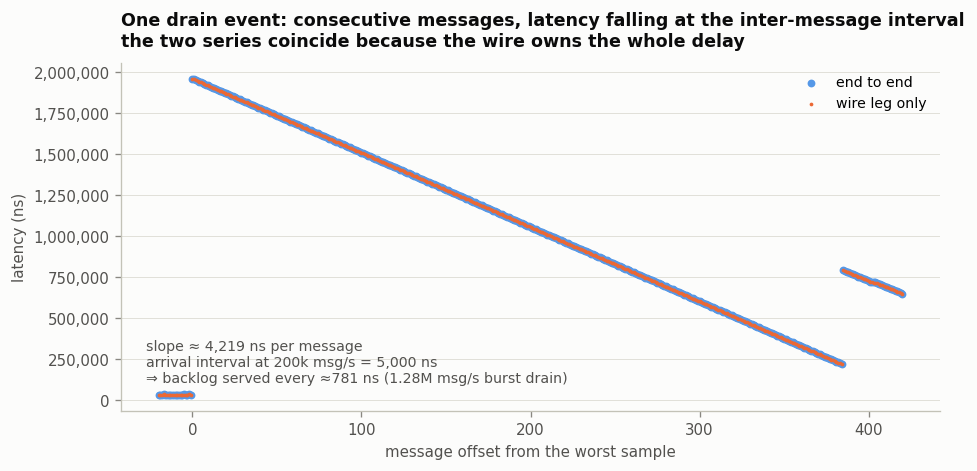

In [8]:
de = pd.read_csv(PLOTS / "drain_event.csv").sort_values("offset")

fig, ax = plt.subplots(figsize=(8.0, 4.0))
# End-to-end drawn larger and underneath, wire smaller on top: the two coincide, and
# this way the coincidence is visible as a blue halo instead of looking like a series
# that failed to plot.
ax.scatter(de["offset"], de["latency_ns"], s=22, color=ORD4[1], linewidth=0,
           zorder=3, label="end to end")
ax.scatter(de["offset"], de["wire_ns"], s=5, color=CAT[1], linewidth=0, zorder=4,
           label="wire leg only")
ax.set_title("One drain event: consecutive messages, latency falling at the "
             "inter-message interval\nthe two series coincide because the wire owns "
             "the whole delay")
style(ax, ylabel="latency (ns)", xlabel="message offset from the worst sample")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper right")
# Slope over the descending run, which should match the message interval.
tail = de[de["offset"] >= 0]
if len(tail) > 50:
    slope = np.polyfit(tail["offset"][:400], tail["latency_ns"][:400], 1)[0]
    # Drain interval implied by the slope: messages arrive every 5,000 ns and the
    # backlog shrinks by `slope` per message, so it is being served that much faster.
    drain = 5000 - abs(slope)
    ax.annotate(f"slope ≈ {abs(slope):,.0f} ns per message\n"
                f"arrival interval at 200k msg/s = 5,000 ns\n"
                f"⇒ backlog served every ≈{drain:,.0f} ns "
                f"({1e9/max(drain,1)/1e6:.2f}M msg/s burst drain)",
                xy=(0.03, 0.08), xycoords="axes fraction", color=INK2, fontsize=8.5)
plt.tight_layout(); plt.show()

In [9]:
oa = pd.read_csv(PLOTS / "outlier_attribution.csv")
table(oa.style.format(thousands=",").hide(axis="index"),
      "Table 4 - for every message over 1 ms, which leg was the largest")

Table 4 - for every message over 1 ms, which leg was the largest


leg,count,share_pct
wire_ns,213,100.000000


## 5. Tail curves

Latency against percentile, so the tail gets real width. Each step right is a 10x
rarer event.

**What to look for:** the curves are flat and tightly grouped out to about p99.9,
then bend sharply upward. The bend is the drain event of figure 4 entering the
distribution. Its position moves with rate only because the number of messages
caught inside a fixed-duration stall scales with rate.

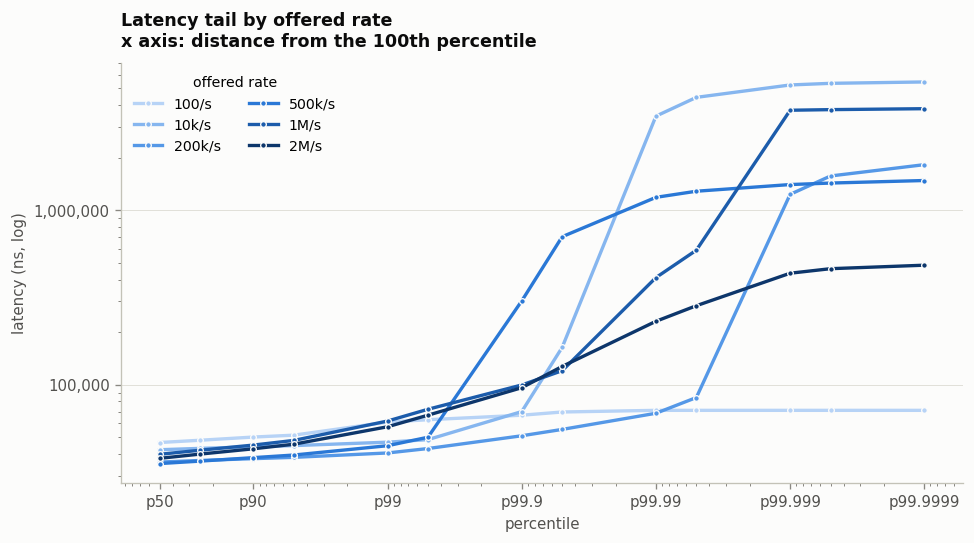

In [10]:
tails = pd.read_csv(PLOTS / "tail_curves.csv")
rates = sorted(tails["rate"].unique())

fig, ax = plt.subplots(figsize=(8.2, 4.6))
for rate, colour in zip(rates, ORD6):
    d = tails[tails["rate"] == rate].sort_values("percentile")
    ax.plot(100 - d["percentile"], d["latency_ns"], color=colour,
            label=rate_fmt(rate) + "/s", marker="o", markersize=3.4,
            markeredgecolor=SURFACE, markeredgewidth=0.8, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()
ax.set_title("Latency tail by offered rate\nx axis: distance from the 100th percentile")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ticks = [50, 10, 1, 0.1, 0.01, 0.001, 0.0001]
ax.set_xticks(ticks); ax.set_xticklabels([f"p{100-t:g}" for t in ticks])
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", title="offered rate", title_fontsize=8.5, ncols=2)
plt.tight_layout(); plt.show()

In [11]:
piv = tails.pivot(index="percentile", columns="rate", values="latency_ns")
piv.columns = [rate_fmt(c) + "/s" for c in piv.columns]
table(piv.style.format(thousands=",", na_rep="—"),
      "Table 5 - latency (ns) at each percentile, by offered rate")

Table 5 - latency (ns) at each percentile, by offered rate


,100/s,10k/s,200k/s,500k/s,1M/s,2M/s
percentile,,,,,,
50.000000,"46,470","42,249","35,876","35,180","39,768","37,696"
75.000000,"47,882","43,011","36,666","36,338","41,967","39,871"
90.000000,"49,953","43,919","37,549","38,061","44,933","42,770"
95.000000,"51,209","44,613","38,202","39,387","47,775","45,440"
99.000000,"60,880","46,685","40,479","44,549","61,730","57,227"
99.500000,"62,815","48,290","42,922","49,838","72,107","66,685"
99.900000,"66,660","69,952","50,804","301,926","99,418","95,886"
99.950000,"69,563","163,320","55,262","705,113","120,060","126,996"
99.990000,"71,097","3,469,682","68,409","1,186,432","410,964","230,643"


## 6. Shape of the bulk

The body of the distribution at 200k msg/s, clipped at p99.9 so it is visible at all.

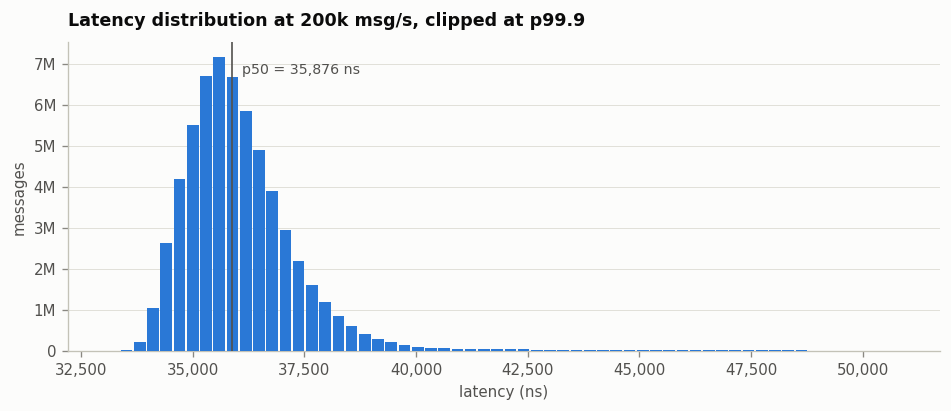

In [12]:
hist = pd.read_csv(PLOTS / "histogram_200000.csv")
mid = (hist["bin_low_ns"] + hist["bin_high_ns"]) / 2
width = (hist["bin_high_ns"] - hist["bin_low_ns"]) * 0.88

fig, ax = plt.subplots(figsize=(8.0, 3.5))
ax.bar(mid, hist["count"], width=width, color=ORD4[2], zorder=3)
p50 = int(lvr.loc[lvr["rate"] == 200000, "p50"].iloc[0])
ax.axvline(p50, color=INK2, lw=1, zorder=4)
ax.annotate(f"p50 = {p50:,} ns", xy=(p50, ax.get_ylim()[1] * 0.9),
            xytext=(6, 0), textcoords="offset points", color=INK2, fontsize=8.5)
ax.set_title("Latency distribution at 200k msg/s, clipped at p99.9")
style(ax, ylabel="messages", xlabel="latency (ns)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))
plt.tight_layout(); plt.show()

## 7. Loss follows packet rate, not message rate

The expectation going in was that a real NIC would start dropping as message rate
climbed, since loopback has no packets-per-second limit worth speaking of. It does
not happen that way, and the reason is batching.

**What to look for:** the only loss in the entire sweep is 0.0088% at 1M msg/s --
and 1M is where *packets* per second peak, at 840k. At 2M msg/s the sender is packing
2.5 messages per datagram, so packets per second fall to 790k and loss returns to
zero. Message rate doubles while packet rate drops, and so does loss.

So the packets-per-second limit is real and we are near it; batching is what keeps
the higher message rates on the safe side of it. That is also the mechanism that
would break first if messages were larger or batching were disabled.

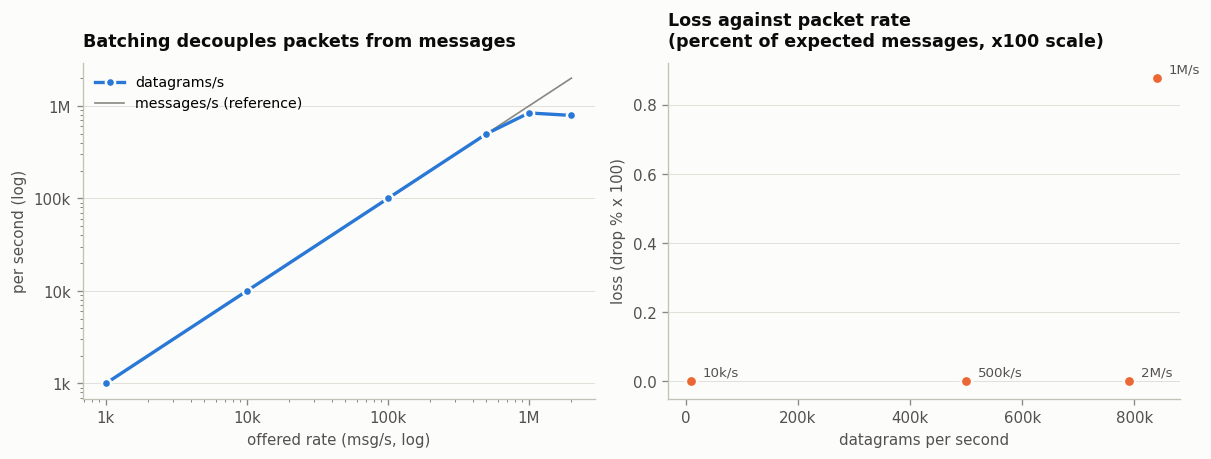

In [13]:
ad = pd.read_csv(PLOTS / "adaptive_redundancy.csv").sort_values("rate")
ad["datagrams_per_s"] = (ad["rate"] / ad["frames_per_datagram"]).round(0)
loss = lvr[["rate", "drop_pct"]]
ad = ad.merge(loss, on="rate", how="left")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

ax = axes[0]
ax.plot(ad["rate"], ad["datagrams_per_s"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3, label="datagrams/s")
ax.plot(ad["rate"], ad["rate"], color=MUTED, lw=1, ls="-", zorder=2,
        label="messages/s (reference)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Batching decouples packets from messages")
style(ax, ylabel="per second (log)", xlabel="offered rate (msg/s, log)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
ax.legend(loc="upper left")

ax = axes[1]
d = ad.dropna(subset=["drop_pct"])
ax.scatter(d["datagrams_per_s"], d["drop_pct"] * 100, s=46, color=CAT[1],
           edgecolor=SURFACE, linewidth=1.5, zorder=3)
for _, r in d.iterrows():
    ax.annotate(rate_fmt(r["rate"]) + "/s",
                (r["datagrams_per_s"], r["drop_pct"] * 100),
                textcoords="offset points", xytext=(7, 3), color=INK2, fontsize=8)
ax.set_title("Loss against packet rate\n(percent of expected messages, x100 scale)")
style(ax, ylabel="loss (drop % x 100)", xlabel="datagrams per second")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
ax.set_ylim(bottom=-0.05)
plt.tight_layout(); plt.show()

In [14]:
t7 = ad[["rate", "frames_per_datagram", "datagrams_per_s", "duplication_pct",
         "drop_pct"]].copy()
t7.columns = ["msg/s", "msgs per datagram", "datagrams/s", "duplication %", "drop %"]
table(t7.style.format({"msg/s": "{:,.0f}", "datagrams/s": "{:,.0f}",
                       "drop %": "{:.4f}"}).hide(axis="index"),
      "Table 7 - the only loss sits at the highest packet rate, not the highest "
      "message rate")

Table 7 - the only loss sits at the highest packet rate, not the highest message rate


msg/s,msgs per datagram,datagrams/s,duplication %,drop %
"1,000",1.000000,"1,000",100.000000,nan
"10,000",1.000000,"10,000",100.000000,0.0000
"100,000",1.000000,"100,000",100.000000,nan
"500,000",1.000000,"500,000",77.700000,0.0000
"1,000,000",1.190000,"840,336",0.400000,0.0088
"2,000,000",2.530000,"790,514",0.000000,0.0000


## 7b. What redundancy actually bought

Duplication was designed against independent loss, where sending everything twice turns
loss probability p into p². That is only as good as the independence assumption.

**First, how much loss there is at all.** Across the sweep with redundancy disabled — 241
million messages — the table below is the entire loss budget. Four of six rates lost
nothing whatsoever, and the only loss sits at the highest packet rate. Nothing approaches
the 0.01%–1% the task treats as realistic, so **this path cannot exercise a loss-recovery
mechanism**. That is a property of the environment, not a claim about the design.

**Second, the loss that does occur is bursty**: 485 lost datagrams arrived in **7 events**,
about 69 consecutive datagrams each.

**What to look for:** the rescue column. A redundant copy follows its original by
microseconds, so it lands inside the same burst and dies with it — 2 rescues out of 485.
Duplication as implemented is nearly useless against the loss this path actually exhibits,
and the p → p² argument does not apply because its independence premise is false here. The
fix it points to is a temporal stagger — hold the copy back by longer than a burst — which
is not implemented because with 2 × 10⁻⁵ loss there is nothing to measure it against.

In [15]:
loss = pd.read_csv(PLOTS / "loss_summary.csv")
t = loss.copy()
t["loss fraction"] = t["dropped"] / t["expected"]
t = t[["rate", "received", "dropped", "loss fraction"]]
t.columns = ["offered rate", "messages", "lost", "loss fraction"]
table(t.style.format({"offered rate": "{:,.0f}", "messages": "{:,.0f}",
                      "lost": "{:,.0f}", "loss fraction": "{:.2e}"}).hide(axis="index"),
      "Table 7b-1 - the entire loss budget of the sweep: 5,262 of 241 million messages")

Table 7b-1 - the entire loss budget of the sweep: 5,262 of 241 million messages


offered rate,messages,lost,loss fraction
100,"16,200",0,0.00e+00
"10,000","1,150,848",0,0.00e+00
"200,000","59,950,848",0,0.00e+00
"500,000","59,950,848",0,0.00e+00
"1,000,000","59,950,848","5,262",8.78e-05
"2,000,000","59,950,848",0,0.00e+00


In [16]:
bl = pd.read_csv(PLOTS / "burst_loss.csv")
t = bl.copy()
t.columns = ["rate", "duplication %", "gap events", "datagrams lost", "per event",
             "rescued by a copy", "rescue %"]
table(t.style.format({"rate": "{:,.0f}", "datagrams lost": "{:,.0f}"}).hide(axis="index"),
      "Table 7b-2 - loss arrives in bursts, and a copy sent microseconds later shares "
      "their fate")

Table 7b-2 - loss arrives in bursts, and a copy sent microseconds later shares their fate


rate,duplication %,gap events,datagrams lost,per event,rescued by a copy,rescue %
"500,000",77.700000,7,485,69.300000,2,0.410000
"1,000,000",0.400000,50,"4,007",80.100000,14,0.350000


## 8. Fan-out to N independent receivers

Each receiver is a separate process with its own socket, its own shared-memory ring
and its own consumer, and the sender transmits a **separate datagram to each**:

```
sender -+- datagram -> receiver 1 -> shm 1 -> consumer 1
        +- datagram -> receiver 2 -> shm 2 -> consumer 2
        +- datagram -> receiver 3 -> shm 3 -> consumer 3
```

Redundancy is disabled for this sweep so receiver count is the only variable. With it
enabled the comparison is confounded: at one receiver there is spare capacity so
duplication runs near 100% and that receiver handles twice the datagrams, while at
three receivers the sender spends its idle time on the extra destinations instead.

**What to look for:** skew grows cleanly with N — about 1.3 µs per additional receiver,
reaching 11.7 µs at ten. The medians rise too, roughly 15 µs from one receiver to ten,
though they do not order cleanly between two and three where the difference is smaller
than the burst events of figure 4.

**The third panel is the finding that matters.** Each receiver costs one more packet per
datagram, so N receivers multiply packet rate by N against a ceiling this path puts at
about 840k datagrams per second. At ten receivers and 500k msg/s the sender was already at
**97% of that ceiling**. The ceiling therefore divides the achievable message rate by
receiver count, and no optimisation above the socket layer changes it — at 50 receivers the
budget allows on the order of 100k msg/s, twenty times below the task's top rate.

Reaching 50 receivers means not sending N copies from one host: network-level multicast,
where packet rate stops depending on N, or a relay tree where each tier fans out to a
bounded number of children at the cost of a hop. Neither is implemented; these
measurements are the argument for why one is necessary.

The receivers also share one host here, so a single NIC carries N copies where N separate
hosts would each carry one.

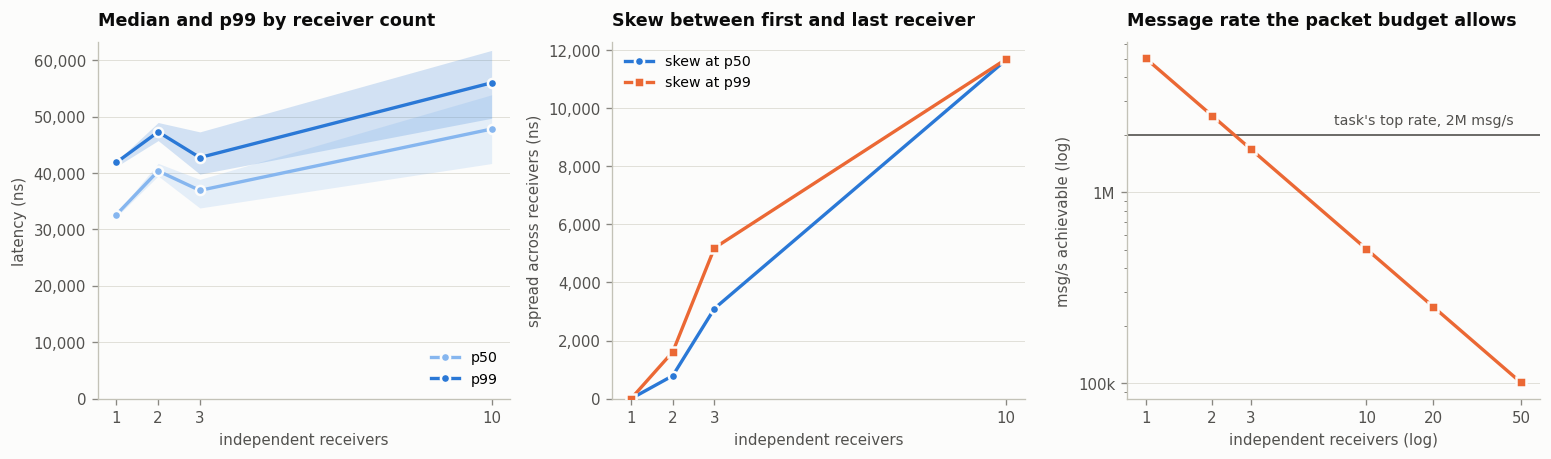

In [17]:
fan = pd.read_csv(PLOTS / "fanout.csv").sort_values("receivers")

budget = pd.read_csv(PLOTS / "pps_budget.csv")
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9))

ax = axes[0]
for (col, label), colour in zip(pcts[:2], (ORD4[0], ORD4[2])):
    ax.fill_between(fan["receivers"], fan[f"{col}_lo"], fan[f"{col}_hi"],
                    color=colour, alpha=0.20, linewidth=0, zorder=2)
    ax.plot(fan["receivers"], fan[col], color=colour, label=label, marker="o",
            markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.set_xticks(fan["receivers"]); ax.set_ylim(bottom=0)
ax.set_title("Median and p99 by receiver count")
style(ax, ylabel="latency (ns)", xlabel="independent receivers")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="lower right")

ax = axes[1]
ax.plot(fan["receivers"], fan["skew_p50"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="skew at p50", zorder=3)
ax.plot(fan["receivers"], fan["skew_p99"], color=CAT[1], marker="s",
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="skew at p99", zorder=3)
ax.set_xticks(fan["receivers"]); ax.set_ylim(bottom=0)
ax.set_title("Skew between first and last receiver")
style(ax, ylabel="spread across receivers (ns)", xlabel="independent receivers")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left")

# The binding limit: each receiver costs another packet, so the measured pps ceiling
# divides the achievable message rate. Arithmetic on a measured ceiling, not a fit.
ax = axes[2]
ax.plot(budget["receivers"], budget["message_rate"], color=CAT[1], marker="s",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.axhline(2_000_000, color=INK2, lw=1, zorder=2)
ax.annotate("task's top rate, 2M msg/s", xy=(budget["receivers"].iloc[-1], 2_000_000),
            xytext=(-4, 6), textcoords="offset points", ha="right", color=INK2,
            fontsize=8.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(budget["receivers"].tolist())
ax.set_xticklabels(budget["receivers"].tolist())
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_title("Message rate the packet budget allows")
style(ax, ylabel="msg/s achievable (log)", xlabel="independent receivers (log)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
plt.tight_layout(); plt.show()

In [18]:
t8 = fan[["receivers", "samples", "p50", "p99", "p99.9", "p99.99",
          "skew_p50", "skew_p99"]].copy()
t8.columns = ["receivers", "samples/run", "p50", "p99", "p99.9", "p99.99",
              "skew p50", "skew p99"]
table(t8.style.format(thousands=",").hide(axis="index"),
      "Table 8 - skew is the clean signal; the medians are within drain-event noise")

Table 8 - skew is the clean signal; the medians are within drain-event noise


receivers,samples/run,p50,p99,p99.9,p99.99,skew p50,skew p99
1,"9,983,616","32,627","41,874","240,756","914,151",0,0
2,"9,983,616","40,352","47,271","68,187","410,565",790,"1,611"
3,"9,983,616","36,909","42,731","56,942","674,272","3,103","5,188"
10,"3,983,616","47,788","55,981","65,252","80,783","11,669","11,691"


## 9. How to put one datagram on N destinations

Three ways, all implemented and measured at **ten destinations** and 200k msg/s — a rate
none of them saturates, so the result reflects per-call cost rather than which one runs out
of headroom first.

One API constraint rules out an obvious hybrid: `sendmmsg` takes **one socket** plus an
array of messages, not an array of sockets. You cannot `connect()` several sockets and then
reach them all in a single `sendmmsg` — N destinations need either N `msg_name`s on one
unconnected socket, or N separate sockets.

| method | syscalls per datagram | destination resolution |
|---|---|---|
| `sendmmsg` | 1 | per message, in-kernel |
| `sendto` x N | N | per call |
| connected sockets, `send` x N | N | once, at `connect()` |

**What to look for:** connected sockets win — 47.8 µs at the median against 52.3 and 50.5,
with the lowest skew between destinations.

**The per-stage split identifies the mechanism, and it is not the obvious one.** The wire
leg is the same for all three within 5% (34.2–36.0 µs). The whole difference sits in the
**source-ring leg** — how long a message waits before the sender reaches it: 5.8 µs for
connected against 8.2 for the others. A cheaper send call drains the ring faster, so less
queues up and fewer messages accumulate per datagram (2.27 against 3.16). End-to-end
latency follows from sender throughput, not from anything happening on the wire.

An earlier version of this notebook explained the same result as the kernel resolving each
destination per `sendmmsg` element while `connect()` resolves once. **That explanation was
wrong** — a route lookup is 100–200 ns and cannot account for a 4.6 µs difference. It also
rested on a loopback comparison, where the three were indistinguishable.

Also worth stating: **`sendto` × 10 could not sustain 1M msg/s at ten destinations at all**
— a workload the other two finish in about 4 seconds had not completed after 12 minutes. It
is ruled out on throughput, not only latency. And the structural argument that one syscall
must beat N has now lost at both 3 and 10 destinations.

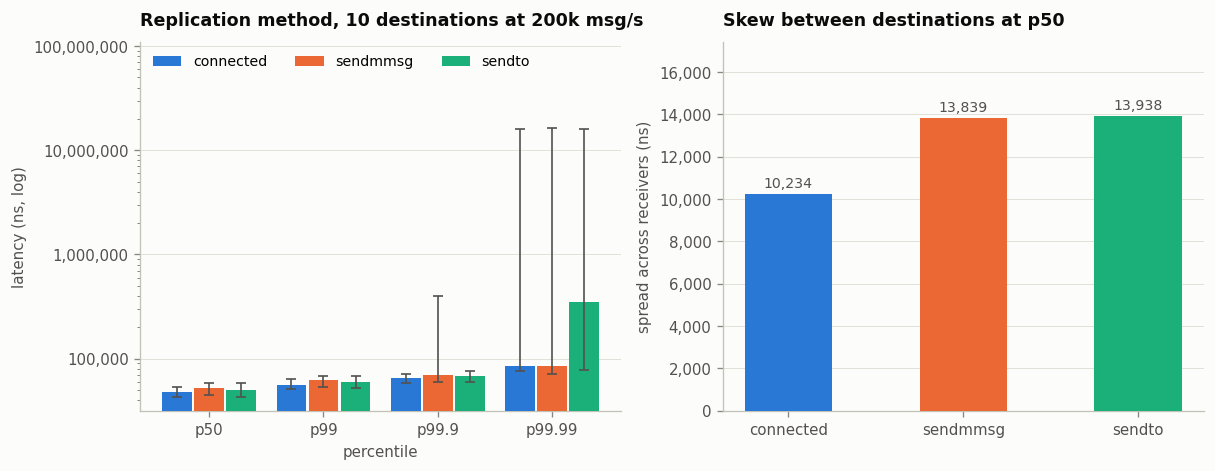

In [19]:
meth = pd.read_csv(PLOTS / "send_methods.csv")
order = ["connected", "sendmmsg", "sendto"]
meth = meth.set_index("method").loc[[m for m in order if m in set(meth["method"])]].reset_index()
cols4 = ["p50", "p99", "p99.9", "p99.99"]
x = np.arange(len(cols4)); w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))
ax = axes[0]
for i, (_, row) in enumerate(meth.iterrows()):
    vals = np.array([row[c] for c in cols4], float)
    lo = np.array([row[f"{c}_lo"] for c in cols4], float)
    hi = np.array([row[f"{c}_hi"] for c in cols4], float)
    off = (i - 1) * (w + 0.02)
    ax.bar(x + off, vals, width=w, color=CAT[i], label=row["method"], zorder=3)
    ax.errorbar(x + off, vals, yerr=[vals - lo, hi - vals], fmt="none",
                ecolor=INK2, elinewidth=1, capsize=3, zorder=4)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(cols4)
ax.set_ylim(top=ax.get_ylim()[1] * 5)
ax.set_title("Replication method, 10 destinations at 200k msg/s")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", ncols=3)

ax = axes[1]
ax.bar(np.arange(len(meth)), meth["skew_p50"], width=0.5,
       color=[CAT[i] for i in range(len(meth))], zorder=3)
for i, v in enumerate(meth["skew_p50"]):
    ax.annotate(f"{v:,.0f}", (i, v), textcoords="offset points", xytext=(0, 4),
                ha="center", color=INK2, fontsize=8.5)
ax.set_xticks(np.arange(len(meth))); ax.set_xticklabels(meth["method"])
ax.set_ylim(bottom=0, top=meth["skew_p50"].max() * 1.25)
ax.set_title("Skew between destinations at p50")
style(ax, ylabel="spread across receivers (ns)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
plt.tight_layout(); plt.show()

In [20]:
t9 = meth[["method", "p50", "p50_lo", "p50_hi", "p99", "p99.9", "skew_p50"]].copy()
t9.columns = ["method", "p50", "p50 lo", "p50 hi", "p99", "p99.9", "skew p50"]
table(t9.style.format(thousands=",").hide(axis="index"),
      "Table 9 - connected sockets, on both median and skew")

Table 9 - connected sockets, on both median and skew


method,p50,p50 lo,p50 hi,p99,p99.9,skew p50
connected,"47,318","42,622","53,941","55,828","64,889","10,234"
sendmmsg,"52,282","44,567","58,752","62,035","69,424","13,839"
sendto,"50,223","43,150","57,738","59,478","67,485","13,938"


## 10. Receive mode, on a real NIC

Kernel busy-poll lets the receiving thread pull packets off the device queue on its
own core instead of waiting for a softirq. Whether that helps depends entirely on
there being a device to poll.

**What to look for:** on a real NIC busy-poll is decisively better — 34.5 µs against
59.0 at the median, and 54.5 against 184.7 at p99.9. On loopback the same comparison
runs the *other* way by a factor of 2.5, because there is no NAPI instance to poll
and the blocking receive just adds a scheduler wake-up per message.

That is why the mode is selected from the bound address rather than exposed as a
flag. Shipping both would mean shipping "these settings for a NIC, those for
loopback" and expecting the operator to know which they have.

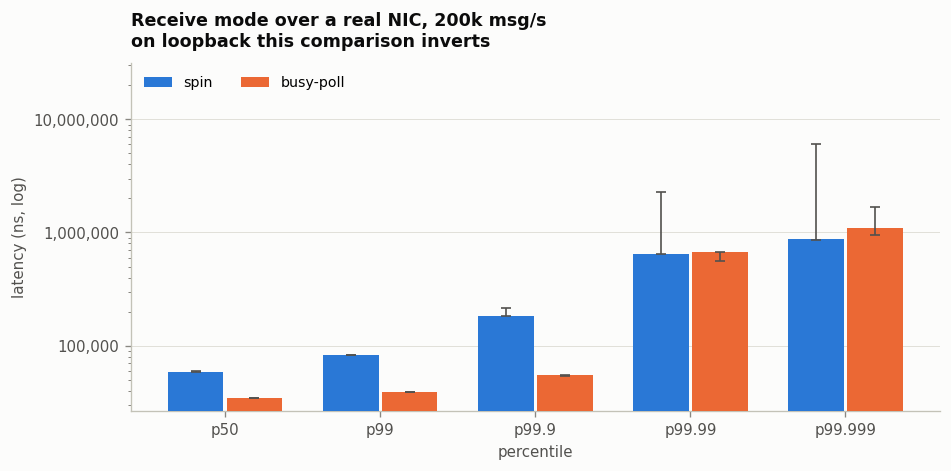

In [21]:
modes = pd.read_csv(PLOTS / "receive_modes.csv")
modes = modes.set_index("mode").loc[["spin", "busy-poll"]].reset_index()
cols5 = ["p50", "p99", "p99.9", "p99.99", "p99.999"]
x = np.arange(len(cols5)); w = 0.36

fig, ax = plt.subplots(figsize=(8.0, 4.0))
for i, (_, row) in enumerate(modes.iterrows()):
    vals = np.array([row[c] for c in cols5], float)
    lo = np.array([row[f"{c}_lo"] for c in cols5], float)
    hi = np.array([row[f"{c}_hi"] for c in cols5], float)
    off = (i - 0.5) * (w + 0.02)
    ax.bar(x + off, vals, width=w, color=CAT[i], label=row["mode"], zorder=3)
    ax.errorbar(x + off, vals, yerr=[vals - lo, hi - vals], fmt="none",
                ecolor=INK2, elinewidth=1, capsize=3, zorder=4)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(cols5)
ax.set_ylim(top=ax.get_ylim()[1] * 4)
ax.set_title("Receive mode over a real NIC, 200k msg/s\n"
             "on loopback this comparison inverts")
style(ax, ylabel="latency (ns, log)", xlabel="percentile")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(ns))
ax.legend(loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

In [22]:
t10 = modes[["mode", "samples", "p50", "p99", "p99.9", "p99.99", "p99.999", "max"]].copy()
t10.columns = ["mode", "samples/run", "p50", "p99", "p99.9", "p99.99", "p99.999", "max"]
table(t10.style.format(thousands=",").hide(axis="index"),
      "Table 10 - busy-poll wins through p99.9; beyond that both are inside "
      "drain-event territory")

Table 10 - busy-poll wins through p99.9; beyond that both are inside drain-event territory


mode,samples/run,p50,p99,p99.9,p99.99,p99.999,max
spin,"9,983,616","58,965","82,893","184,721","644,182","867,923","991,237"
busy-poll,"9,983,616","34,521","39,194","54,517","667,503","1,096,806","1,330,314"


## 11. Redundancy and batching hand off without configuration

Both follow one principle: use spare capacity, never delay a message. The sender
re-sends the previous datagram only when the source ring is empty, so redundancy
consumes time it had nothing better to do with, and batching packs whatever is
already available without ever waiting.

**What to look for:** duplication holds at 100% to 100k msg/s, is still 78% at 500k,
and reaches zero by 1M — before packet rate becomes the constraint identified in
figure 7. Batching rises to take over as it does. No threshold, no knob.

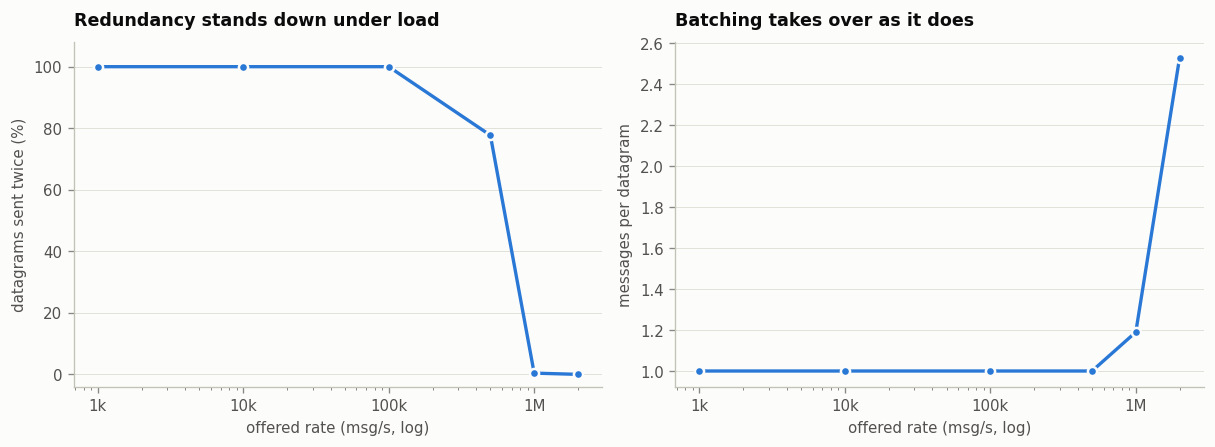

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
ax = axes[0]
ax.plot(ad["rate"], ad["duplication_pct"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.set_xscale("log"); ax.set_ylim(-4, 108)
ax.set_title("Redundancy stands down under load")
style(ax, ylabel="datagrams sent twice (%)", xlabel="offered rate (msg/s, log)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))

ax = axes[1]
ax.plot(ad["rate"], ad["frames_per_datagram"], color=ORD4[2], marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
ax.set_xscale("log")
ax.set_title("Batching takes over as it does")
style(ax, ylabel="messages per datagram", xlabel="offered rate (msg/s, log)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(rate_fmt))
plt.tight_layout(); plt.show()

## 12. Message footprint

The original harness format carried every price and size twice (a `double` and a
scaled integer), values derivable from others, 85 bytes of padding across three
types, and the symbol and venue as 32 bytes of text on every message. Field-by-field
reasoning is in the write-up; `harness/include/message.h` is the result.

**What to look for:** the largest frame sets the shared-memory ring slot size, so
shrinking `OrderBook` shrinks every ring hop too. Smaller messages are also what let
batching pack more per datagram, which is the mechanism keeping packet rate below the
NIC's limit in figure 7.

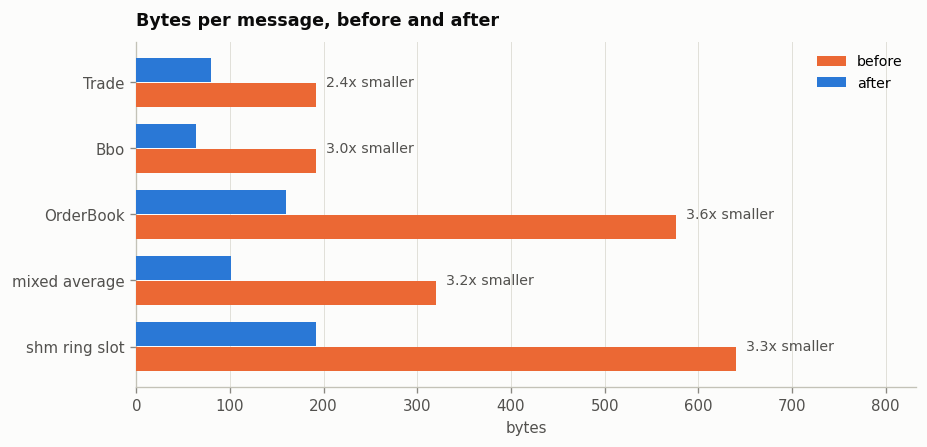

In [24]:
sizes = pd.read_csv(PLOTS / "message_sizes.csv")
y = np.arange(len(sizes)); h = 0.36

fig, ax = plt.subplots(figsize=(7.8, 3.8))
ax.barh(y + (h + 0.02) / 2, sizes["before_bytes"], height=h, color=CAT[1],
        label="before", zorder=3)
ax.barh(y - (h + 0.02) / 2, sizes["after_bytes"], height=h, color=CAT[0],
        label="after", zorder=3)
for i, row in sizes.iterrows():
    ax.annotate(f"{row['before_bytes']/row['after_bytes']:.1f}x smaller",
                (row["before_bytes"], i), textcoords="offset points",
                xytext=(6, 0), va="center", color=INK2, fontsize=8.5)
ax.set_yticks(y); ax.set_yticklabels(sizes["message"]); ax.invert_yaxis()
ax.set_xlim(0, sizes["before_bytes"].max() * 1.30)
ax.set_title("Bytes per message, before and after")
style(ax, xlabel="bytes", grid_axis="x")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## Clock synchronisation

Every cross-host figure is `recv_ts` on the receiving host minus `send_ts_ns` stamped
on the sending host — two clocks — so it is worth stating what that does and does not
affect.

**What we rely on.** chrony keeps the hosts synchronised to well within 3
microseconds; measured RMS offset during these runs was a few hundred nanoseconds on
both. `chronyc tracking` is captured before *and* after each long run rather than
once at the start.

**A static offset is mostly harmless.** A constant offset shifts every sample
equally, so it biases absolute medians but cancels exactly in anything comparative —
distribution shape, the gap between p50 and p99.999, and every
configuration-versus-configuration result here. Nearly all conclusions in this
notebook are comparative.

**Drift is the real hazard**, because an offset that moves during a run smears the
distribution and can pass for tail latency. Hence the before-and-after capture.

**Which figures depend on it at all.** Of the four legs in figure 2, only the wire
leg spans two clocks. Source-ring, publish and post-publish are each measured on a
single host, and those are the legs carrying our own code's cost — so the claim that
our code contributes ~620 ns needs no clock agreement whatsoever. Three further
cross-checks: ICMP round-trip halved is an upper bound owing nothing to
synchronisation, and our one-way figures sit below it as expected since ICMP is
deprioritised; the drain-event slope in figure 4 matches the known message interval,
which it could not if clocks were drifting materially; and the four legs sum to the
independently measured end-to-end value (35,075 against 35,325 ns).

**Residual uncertainty, not claimed away.** chrony's root dispersion here is tens of
microseconds, which bounds accuracy against absolute UTC — but the relevant quantity
is the *relative* offset between hosts tracking the same sources, which is far
smaller. Absolute one-way latencies carry a small systematic uncertainty; the
comparative results do not. Tightening it would mean NIC hardware timestamping, PTP
against the instance family's hardware clock, or a reflector design where one host
stamps both departure and return.

## Conclusions

**What the measurements support.** Over a real NIC between two hosts on one subnet:
35 µs median, 39 µs at p99, 50 µs at p99.9, 68 µs at p99.99, and **zero loss across
the task's entire stated rate range** from 100 to 2M events per second. Latency is
essentially flat across that range — the *lowest* rate has the highest median,
because at 10 ms between messages everything is cold.

**Our transport is not the limiting factor, and the data says so precisely.** Of the
35 µs median, our sender accounts for 305 ns, publishing 50 ns, and the consumer's
pickup 264 ns — about 1.8% in total, staying under 1 µs even at p99.999. The other
98% is kernel TX, NIC, wire and kernel RX. There is no remaining optimisation in our
code that could move the median; the only lever left is bypassing the kernel network
stack.

**Spikes are bursty, not uniform, and that is the most useful thing we learned about
the tail.** Above 500 µs there are *no* isolated occurrences at all — 100% sit inside
bursts of consecutive messages, and a whole 20M-message run contains one to three of
them. All 213 messages over 1 ms are wire-dominated and arrive as consecutive sequence
ids whose latency falls at exactly the inter-message interval: a queue stalling ~2 ms
and then draining.

Two consequences. A far-tail percentile from a short run is meaningless, because
whether it captures a burst is luck. And the fix is not "shave microseconds" — it is to
find and remove one recurring stall.

**Loss follows packet rate, not message rate**, and batching is what exploits that:
the only loss observed is at the highest packets-per-second point, and doubling the
message rate from 1M to 2M *reduces* both packet rate and loss.

**Decisions the measurements drove, against prior reasoning.**

- *Connected sockets over `sendmmsg`.* The structural argument favoured `sendmmsg`
  and was wrong on a real NIC.
- *Busy-poll on a device, spin on loopback.* The same comparison inverts between the
  two, by a factor of 2.5 in one direction and 1.7 in the other — so the transport
  decides from the path rather than exposing a flag.
- *Duplication over retransmission or FEC.* Strictly monotonic delivery means a late
  repair cannot be inserted at all, so only redundancy that costs no latency is worth
  anything.
- *Format work over tuning.* Shrinking messages 3.2x did more for headroom than any
  socket or core setting.

## Next steps

Two independent lines of work, cost-ordered within each.

### Reduce the latency

The stage decomposition leaves **98% of the latency, and 100% of the large spikes, in the
kernel network path**, with our own code at ~620 ns. Nothing above the kernel can move the
median, so the task is to establish what the kernel contributes and then remove it.

1. **io_uring — cheapest, and worth doing first.** No privileges, no XDP program, no
   interface binding; `liburing` is packaged and the change is confined to how the sender
   and receiver issue I/O. Multishot receive with provided buffers takes the per-packet
   syscall off the receive path, and `DEFER_TASKRUN` moves kernel task work to a controlled
   point rather than an arbitrary one. **What it can and cannot answer:** it does not bypass
   the kernel network stack, so it cannot rule out interference from that stack, and
   removing a ~100 ns syscall cannot move a 34 µs wire leg. What it plausibly can do is
   raise the burst drain rate — measured at about 1.3M msg/s — which would shorten the
   events that dominate the far tail. A cheap test of a specific hypothesis rather than a
   general speed-up.
2. **AF_XDP — the experiment that actually tests kernel interference.** Bypasses the network
   stack on a stock kernel, with no hugepages and no driver replacement. If the bursts
   disappear the kernel was the cause; if they survive, the NIC or the fabric is. Binding an
   XDP socket to a live NIC queue is disruptive, so this is gated on explicit confirmation
   and a dedicated interface.
3. **DPDK — the primary late-game solution.** If bypass proves to be the lever, this is
   where the lowest and most predictable latency lives: a full userspace driver with no
   per-packet kernel involvement. Materially more expensive to set up and to reproduce, so
   it follows the AF_XDP result rather than preceding it.

### Make the loss and fan-out stories real

4. **Measure on an L3 path, and on one with a realistic loss pattern.** Everything the
   design claims about loss is untestable at 2 × 10⁻⁵, and the independence premise behind
   duplication is already known to be false here.
5. **Stagger the redundant copy** by longer than a burst and see whether the rescue rate
   moves off 0.4%. A small sender change needing nothing from the receiver — but only worth
   doing where there is loss to rescue.
6. **Multicast or a relay tree for fan-out.** The packet budget divides the achievable
   message rate by receiver count, so unicast replication cannot reach 50 receivers at any
   interesting rate. This is the only item here that changes an asymptote rather than a
   constant.

**Honest limitations.**

- p99.999 rests on ~200 observations per run and varies by a factor of two between
  repetitions. It is reported, but the drain event dominates it and it should not be
  read as a property of the transport.
- Fan-out is measured to 3 independent receivers and extrapolated, not measured, at
  the 50 the task contemplates. Skew grows linearly, which implies roughly 150 µs of
  replication cost at 50 receivers — serial unicast is the wrong mechanism at that
  scale, and multicast or a relay tree would be needed.
- The receivers in the fan-out sweep share one host, so one NIC carries N copies.
- The ~2 ms drain events are unattributed beyond "the wire". Distinguishing sender
  kernel TX from NIC from receiver kernel RX needs NIC hardware timestamps, which we
  do not collect.
- One host is virtualised and one bare metal. We tested specifically for
  hypervisor-induced periodicity with simultaneous opposite-direction streams over 15
  minutes and found none (autocorrelation at 300 s lag: −0.02 and −0.09).
- Loss resilience is verified functionally — duplication rescues, the gate suppresses
  duplicates and stragglers exactly — but not under deliberately injected loss, so
  the p → p² claim is reasoned rather than measured.